# Projects (30 pts):

Suppose $S_1(t)$ and $S_2(t)$ are independent stock processes with equal volatility. $S_1(0)=S_2(0)=100.$
The contract at maturity pays the value of the most expensive stock: $V(T)=\max_i\{S_1(T),S_2(T)\}.$
* What is the formula for the fair value of the contract, $V(0)$?         
* Derive the partial differential equation for this contract              
* Solve the resultant PDE using Finite Difference Method                   
* Compare the results obtained through solving the PDE with Monte Carlo Method

### Fair value:

The formula for the fair value of the contract, $V(0)$, is

$$V(0) = 2 S_0 N\left(\frac{\sigma \sqrt T}{\sqrt 2}\right),$$

where $N$ denotes the standard normal CDF.

In [22]:
from scipy.stats import norm

def analytic_FV(S_0, sigma, T):
    return 2 * S_0 * norm.cdf(sigma * np.sqrt(T) / np.sqrt(2))

### PDE derivation:

Let's define the price of the option as $V\left(S_1(t), S_2(t), t\right)$. Then, using Ito's formula and the fact that $S_1$ and $S_2$ are independent stock processes, we obtain:

$$V(S_1(t), S_2(t), t) = V(S_1(0), S_2(0), 0) + \int_0^t (\partial _tV)(S_1(u), S_2(u), u) du + \int_0^t (\partial _1V)(S_1(u), S_2(u), u) dS_1(u) + \int_0^t (\partial _2V)(S_1(u), S_2(u), u) dS_2(u) + \frac{1}{2} \int_0^t (\partial _{11}V)(S_1(u), S_2(u), u) d[S_1]_u + \frac{1}{2} \int_0^t (\partial _{22}V)(S_1(u), S_2(u), u) d[S_2]_u.$$

Using shorthand notation, we write this as

$$dV =  V^\prime_t du + V^\prime_1 dS_1(u) + V^\prime_2 dS_2(u) + \frac{1}{2} V^{\prime\prime}_{11} d[S_1]u + \frac{1}{2} V^{\prime\prime}_{22} d[S_2]u.$$

We have that

$$dS_i(t) = rS_i(t)dt + \sigma S_i(t)dW_i(t)$$

for $i = 1, 2$, where $W_1$ and $W_2$ are independent Wiener-processes. From this, we can rewrite

$$d[S_i]_t = \sigma ^2 S_i^2(t) dt$$

for $i = 1, 2$.

Substituting into the formula for $dV$, we get

$$dV = V^\prime_t dt + V^\prime_1 r S_1(t)dt + V^\prime_2 r S_2(t)dt + \frac{1}{2} V^{\prime\prime}_{11} \sigma^2 S^2_1(t) dt + \frac{1}{2} V^{\prime\prime}_{22} \sigma^2 S^2_2(t) + V^\prime_1 \sigma S_1(t)dW_1(t) + V^\prime_2 \sigma S_2(t)dW_2(t).$$

Thus, the riskless portfolio is

$$\Pi = - V + V^\prime_1 S_1 + V^\prime_2 S_2.$$

From here, using $d\Pi = r\Pi dt$, we obtain the PDE

$$\frac{\partial V}{\partial t} + \frac{1}{2}\sigma^2 S_1^2\frac{\partial V^2}{\partial S_1^2} + \frac{1}{2}\sigma^2 S_2^2\frac{\partial V^2}{\partial S_2^2} + rS_1 \frac{\partial V}{\partial S_1} + rS_2 \frac{\partial V}{\partial S_2} - rV =0.$$

Using the usual substitution of $x = \log(\frac{S_1}{S_0}), y = \log(\frac{S_2}{S_0})$, we obtain

$$-\frac{\partial V(x,y,t)}{\partial t} = \left[-r + \left(r-\frac{\sigma^2}{2}\right)\left(\frac{\partial}{\partial x} + \frac{\partial}{\partial y}\right) + \frac{\sigma^2}{2}\left(\frac{\partial ^2}{\partial x^2} + \frac{\partial ^2}{\partial y^2}\right)\right]V(x,y,t).$$

### Boundaries and discretization:

For terminal and boundary conditions, we have:

$$V(S_1, S_2, T) = \max (S_1, S_2), \quad V(0, S_2, t) = S_2, \quad V(S_1, 0, t) = S_1, \quad \lim_{S_1 \to \infty}V(S_1, S_2, t) = S_1, \quad \lim_{S_2 \to \infty}V(S_1, S_2, t) = S_2.$$

After substitution and discretization on $[x_{min}, x_{max}]\times[y_{min}, y_{max}]$, this can be approximated using

$$V(x, y, T) = S_0 \max (\mathrm{e}^x, \mathrm{e}^y), \quad V(x_{min}, y, t) = S_0 \max (\mathrm{e}^{x_{min}}, \mathrm{e}^y), \quad V(x, y_{min}, t) = S_0 \max (\mathrm{e}^x, \mathrm{e}^{y_{min}}), \quad V(x_{max}, y, t) = S_0 \max (\mathrm{e}^{x_{max}}, \mathrm{e}^y), \quad V(x, y_{max}, t) = S_0 \max (\mathrm{e}^x, \mathrm{e}^{y_{max}}).$$

It is apparent, that these boundary conditions are constant across all time steps, thus we only need to set them once.

For the interior of the domain, we use the following stencil to calculate $V(t_{n-1})$ from $V(t_n)$ and its neighbors:

\begin{pmatrix}
0 & \Delta t \left[ -\frac{r - \frac{\sigma^2}{2}}{2 \Delta x} + \frac{\sigma^2}{2 \Delta x^2} \right] & 0 \\
\Delta t \left[ -\frac{r - \frac{\sigma^2}{2}}{2 \Delta y} + \frac{\sigma^2}{2 \Delta y^2} \right] & \Delta t \left[ -r - \frac{\sigma^2}{\Delta x^2} - \frac{\sigma^2}{\Delta y^2} \right] + 1 & \Delta t \left[ \frac{r - \frac{\sigma^2}{2}}{2 \Delta y} + \frac{\sigma^2}{2 \Delta y^2} \right] \\
0 & \Delta t \left[ \frac{r - \frac{\sigma^2}{2}}{2 \Delta x} + \frac{\sigma^2}{2 \Delta x^2} \right] & 0
\end{pmatrix}

Here we used a backward difference for the time derivative and a central difference for the spatial derivatives.

In [25]:
import numpy as np
from scipy.signal import correlate2d

In [5]:
S_0 = 100
T = 2

sigma = 0.03
r = 0.05

x_min, x_max = -5, 2
y_min, y_max = -5, 2

In [6]:
def create_terminal(n_x, n_y):
    x = np.linspace(x_min, x_max, n_x)
    y = np.linspace(y_min, y_max, n_y)
    
    # reshape for broadcasting
    X = x[:, None]   # shape (n_x, 1)
    Y = y[None, :]   # shape (1, n_y)
    
    grid = S_0 * np.maximum(np.exp(X), np.exp(Y))
    
    return grid

In [74]:
def create_and_run_explicit_BS(n_x, n_y, n_t):
    
    assert (n_x - 1) % (x_max - x_min) == 0, \
        f"n_x - 1 ({n_x - 1}) must be divisible by x_max-x_min ({x_max-x_min}) for 0 to land on the grid)"
    
    dx = (x_max - x_min) / (n_x - 1)
    dy = (y_max - y_min) / (n_y - 1)
    dt = T / (n_t - 1)
    
    assert dt <= 1 / (r + sigma**2 / dx**2 + sigma**2 / dy**2), \
        f"convergence criterion is not fulfilled"
    
    explicit_spatial_grid = create_terminal(n_x, n_y)
    
    # create stencil
    diff_x_first = (r - sigma**2 / 2) / (2 * dx)
    diff_x_second = sigma**2 / (2 * dx**2)
    diff_y_first = (r - sigma**2 / 2) / (2 * dy)
    diff_y_second = sigma**2 / (2 * dy**2)
    center = -1.0 * r - sigma**2 / (dx**2) - sigma**2 / (dy**2)
    
    stencil = np.array([
        [0, dt * (-1.0 * diff_x_first + diff_x_second), 0],
        [dt * (-1.0 * diff_y_first + diff_y_second), dt * center + 1, dt * (diff_y_first + diff_y_second)],
        [0, dt * (diff_x_first + diff_x_second), 0]
    ])
    
    for _ in range(n_t - 1, 0, -1):
        explicit_spatial_grid_new_interior = correlate2d(explicit_spatial_grid, stencil, mode="valid")
        explicit_spatial_grid[1:-1, 1:-1] = explicit_spatial_grid_new_interior
    
    return explicit_spatial_grid

In [9]:
import numpy as np
from matplotlib import cm
import matplotlib.pyplot as plt

# plotter lifted from lecture codes, modified slightly to rescale xs and ys
def plot_2d(x_min_max_Nstep, y_min_max_Nstep, analytic_func=None, grid_values=None,
            labels={'x':'x', 'y':'t', 'z':'Value'}, z_lim=None):
    assert (analytic_func is not None or grid_values is not None), "Analytical function or grid_values needed as imput"
    for needed_label in ['x', 'y', 'z']:
        assert needed_label in labels, f"The {needed_label} is missing from {labels}"
    if grid_values is not None:
        exp_grid_shape = (y_min_max_Nstep[2], x_min_max_Nstep[2], )
        assert grid_values.shape == exp_grid_shape,\
                f"Incorrect Grid shape: expected: {exp_grid_shape}, actual: {grid_values.shape}"
    
    xs = np.exp(np.linspace(*x_min_max_Nstep)) * S_0
    ys = np.exp(np.linspace(*y_min_max_Nstep)) * S_0
    grid_x, grid_y = np.meshgrid(xs, ys)
    fig, ax = plt.subplots(subplot_kw={'projection': '3d'})
    if analytic_func is not None:
        values = analytic_func(grid_x, grid_y)
        ax.plot_surface(grid_x, grid_y, values, cmap=cm.coolwarm, linewidth=0, antialiased=False, alpha=0.8)
    if grid_values is not None:
        ax.plot_surface(grid_x, grid_y, grid_values, cmap=cm.coolwarm, linewidth=0, antialiased=False, alpha=0.8)
    ax.set_xlabel(labels['x'], fontweight='bold')
    ax.set_ylabel(labels['y'], fontweight='bold')
    ax.set_zlabel(labels['z'], fontweight='bold')
    if z_lim is not None:
        ax.set_zlim(*z_lim)    
    plt.show()
    if analytic_func is not None and grid_values is not None:
        diff = grid_values-values
        fig, ax = plt.subplots(subplot_kw={'projection': '3d'})
        ax.plot_surface(grid_x, grid_y, diff, cmap=cm.coolwarm, linewidth=0, antialiased=False, alpha=0.8)
        ax.set_xlabel(labels['x'], fontweight='bold')
        ax.set_ylabel(labels['y'], fontweight='bold')
        ax.set_zlabel(labels['z'], fontweight='bold')
        ax.title.set_text("Diff")        
        plt.show()

In [71]:
n_x, n_y, n_t = 211, 211, 111
option_price_solution = create_and_run_explicit_BS(n_x, n_y, n_t)

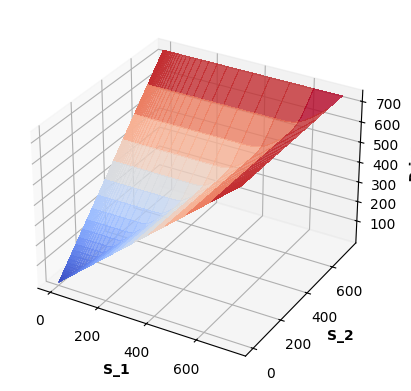

In [72]:
plot_2d((x_min, x_max, n_x), (y_min, y_max, n_y), grid_values = option_price_solution.T, labels={'x':'S_1', 'y':'S_2', 'z':'Price'})

In [73]:
# Simple check using analytic formula:

x = np.linspace(x_min, x_max, n_x)
y = np.linspace(y_min, y_max, n_y)

idx_x = np.where(x == 0)[0][0]
idx_y = np.where(y == 0)[0][0]

print(f'Option price using PDE solution: {option_price_solution[idx_x, idx_y]}')
print(f'Option price using analytic formula: {analytic_FV(S_0, sigma, T)}')

Option price using PDE solution: 102.33731329604872
Option price using analytic formula: 102.39329468282253


### Monte-Carlo:

In [27]:
eps_1 = np.random.standard_normal(2)
eps_2 = np.random.standard_normal(2)

eps_1, eps_2

(array([-0.0366562 ,  0.85147231]), array([ 1.06068198, -0.55325758]))

In [45]:
def MC_FV(n_t, num_paths):
    dt = T / (n_t - 1)
    path_payoffs = np.empty(num_paths)
    for path in range(0, num_paths):
        trajectory_1 = np.empty(n_t)
        trajectory_2 = np.empty(n_t)
        trajectory_1[0] = S_0
        trajectory_2[0] = S_0
        epsilon_1 = np.random.standard_normal(n_t - 1)
        epsilon_2 = np.random.standard_normal(n_t - 1)
        for n in range(0, n_t - 1):
            trajectory_1[n + 1] = trajectory_1[n] + r * trajectory_1[n] * dt + sigma * trajectory_1[n] * epsilon_1[n] * np.sqrt(dt)
            trajectory_2[n + 1] = trajectory_2[n] + r * trajectory_2[n] * dt + sigma * trajectory_2[n] * epsilon_2[n] * np.sqrt(dt)
        path_payoffs[path] = np.max([trajectory_1[-1], trajectory_2[-1]])
    expected_payoff = np.mean(path_payoffs)
    df = np.exp(-1.0 * r * T)
    fv = df * expected_payoff
    return fv

In [47]:
MC_FV(511, 1000)

102.31573430583951